In [1]:
# Import necessary libraries
import pandas as pd
from google.colab import files

# Upload the dataset
print("Please upload your returns data CSV file:")
uploaded = files.upload()

# Load the first (and assumed only) uploaded file
filename = list(uploaded.keys())[0]
df = pd.read_excel(filename)

# Display basic structure
print("Dataset dimensions:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nData types:\n", df.dtypes)

# Preview first and last 5 rows
print("\nFirst 5 rows:\n", df.head())
print("\nLast 5 rows:\n", df.tail())

Please upload your returns data CSV file:


Saving Log Transformed Data.xlsx to Log Transformed Data.xlsx
Dataset dimensions: (1321, 8)

Column names: ['Dates', 'US CDS', 'UK CDS', 'German CDS', 'Silver', 'Copper', 'Bitcoin', 'Gold']

Data types:
 Dates         datetime64[ns]
US CDS               float64
UK CDS               float64
German CDS           float64
Silver               float64
Copper               float64
Bitcoin              float64
Gold                 float64
dtype: object

First 5 rows:
        Dates   US CDS   UK CDS  German CDS    Silver    Copper    Bitcoin  \
0 2021-01-01  3.55897  3.55897    2.374999  3.276579  8.955319  10.283655   
1 2021-01-04  3.55897  3.55897    2.382782  3.305787  8.967504  10.342948   
2 2021-01-05  3.55897  3.55897    2.371271  3.314550  8.986509  10.427986   
3 2021-01-06  3.55897  3.55897    2.384165  3.315095  8.991002  10.489586   
4 2021-01-07  3.55897  3.55897    2.408835  3.300640  9.007857  10.589937   

       Gold  
0  7.548909  
1  7.571937  
2  7.575590  
3  7.559356  
4

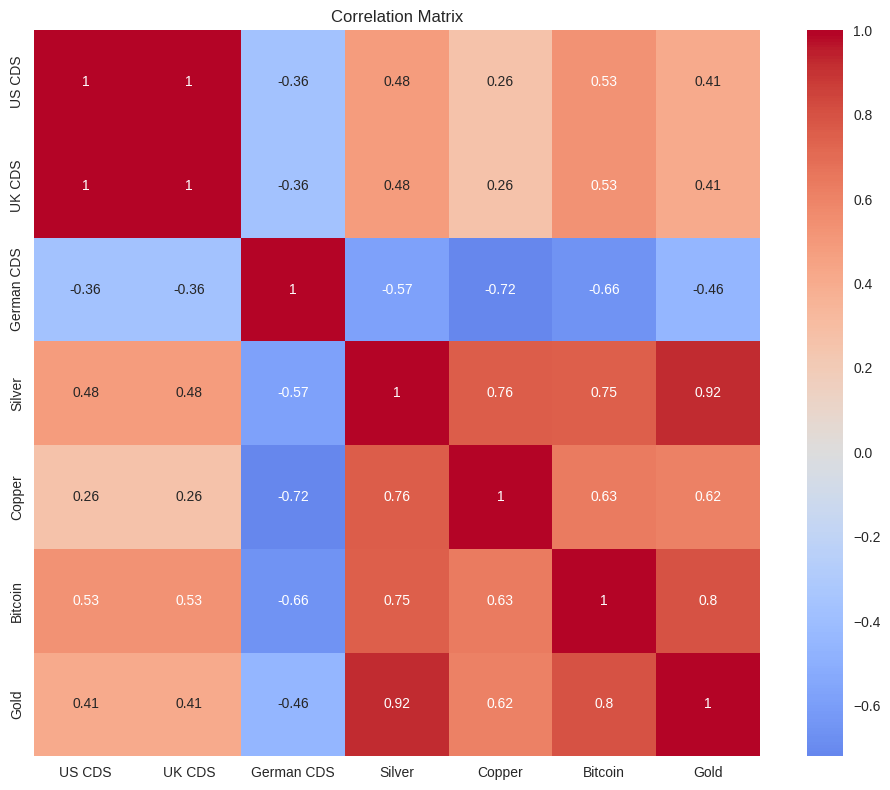

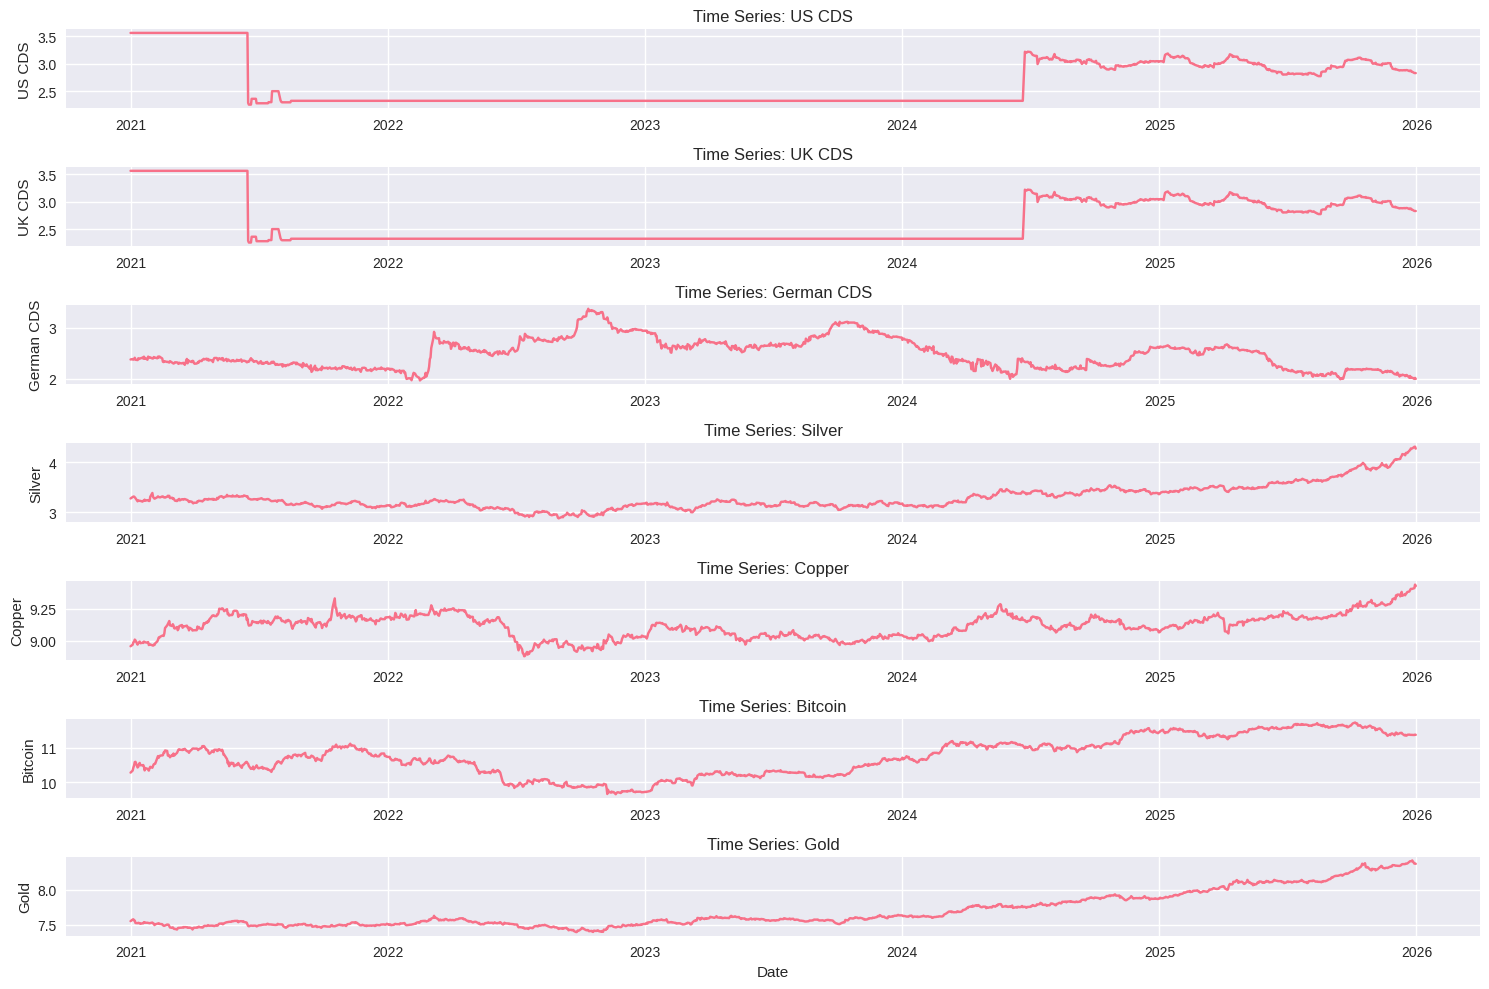

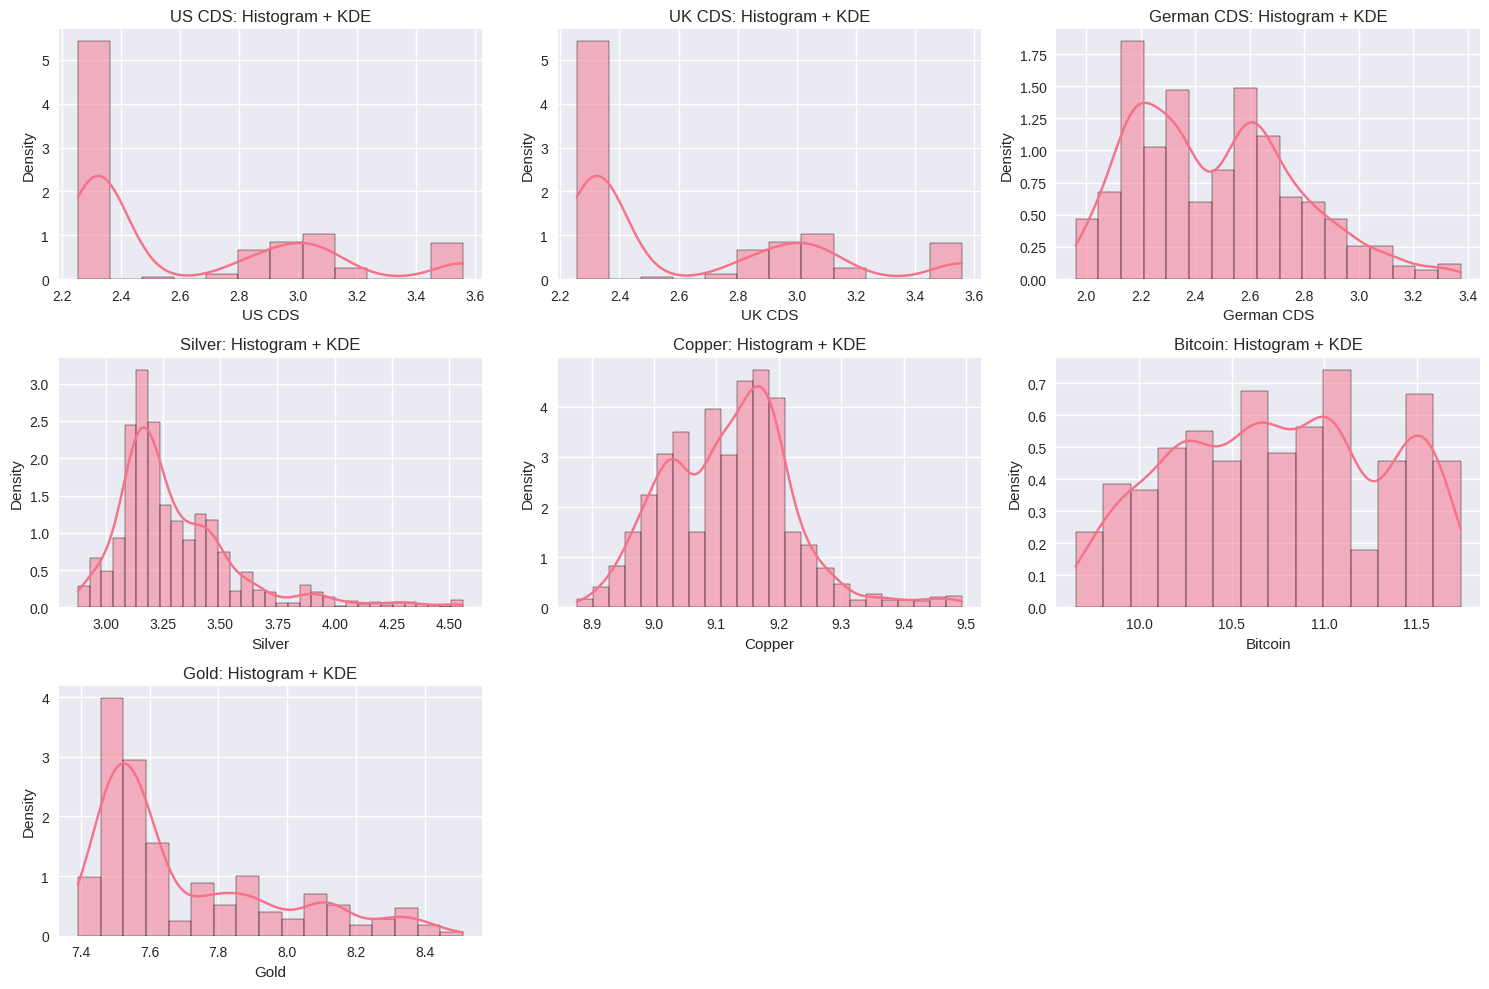

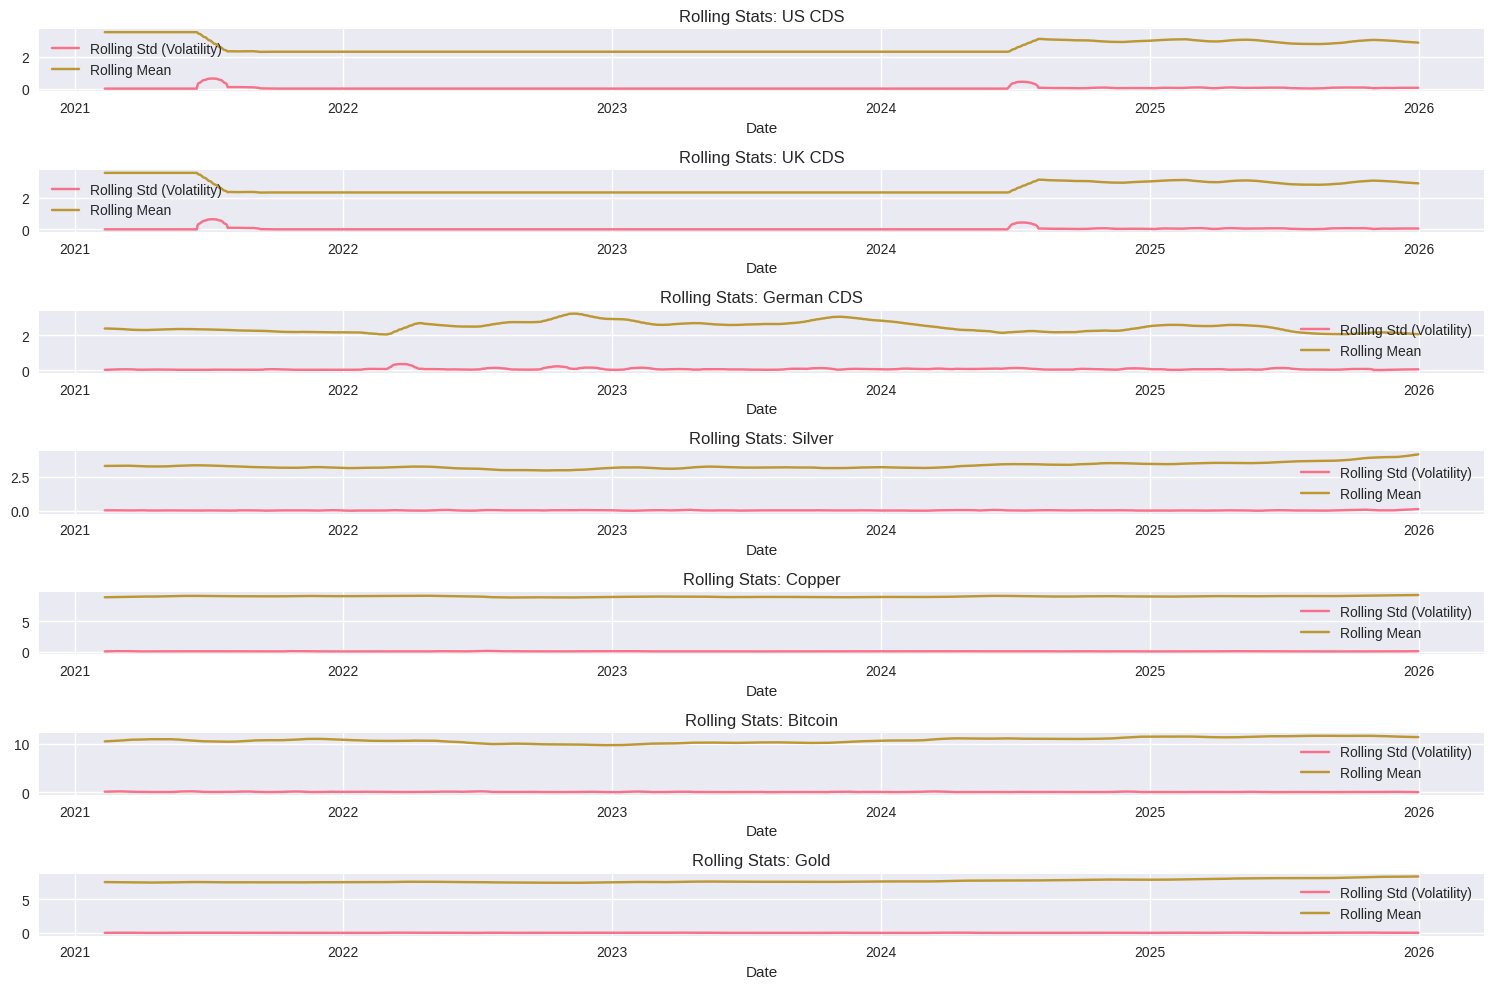

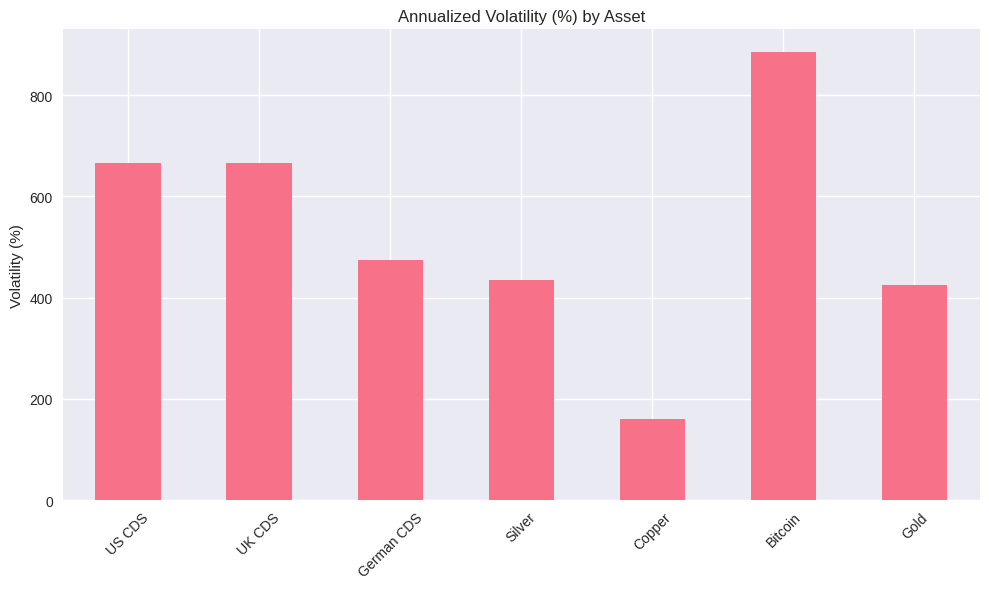

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Assume df is already loaded from previous step
# Set style for plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Identify numeric columns for operations that require them
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
df_numeric = df[numeric_cols]

# 1. Correlation Matrix and Heatmap
plt.figure(figsize=(10, 8))
# df.corr() automatically handles non-numeric columns by excluding them
corr_matrix = df_numeric.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, square=True)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

# 2. Time-Series Plots (all numeric variables against 'Dates')
plt.figure(figsize=(15, 10))
# Check if 'Dates' column exists and use it as x-axis
if 'Dates' in df.columns:
    x_axis = df['Dates']
    # Iterate only over numeric columns for y-axis
    for i, col in enumerate(numeric_cols, 1):
        plt.subplot(len(numeric_cols), 1, i) # Adjusted subplot count
        plt.plot(x_axis, df[col])
        plt.title(f'Time Series: {col}')
        plt.ylabel(col) # Label y-axis with the column name
        if i == len(numeric_cols): # Add xlabel only for the last plot
            plt.xlabel('Date')
else:
    # Fallback if 'Dates' column is not found (though it should be based on previous cell)
    for i, col in enumerate(df.columns, 1):
        plt.subplot(len(df.columns), 1, i)
        plt.plot(df.index, df[col])
        plt.title(f'Time Series: {col}')
        plt.xlabel('Time')
        plt.ylabel(col)
plt.tight_layout()
plt.show()


# 3. Histograms and KDEs
plt.figure(figsize=(15, 10))
# Iterate only over numeric columns
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(len(numeric_cols)//3 + 1, 3, i) # Adjusted subplot count
    sns.histplot(df[col], kde=True, stat='density')
    plt.title(f'{col}: Histogram + KDE')
plt.tight_layout()
plt.show()

# 4. Rolling Statistics (30-day window)
# Apply rolling statistics only on numeric data
rolling_stats = df_numeric.rolling(window=30).agg(['mean', 'std'])
rolling_stats.columns = ['_'.join(col).strip() for col in rolling_stats.columns]
plt.figure(figsize=(15, 10))
# Iterate only over numeric columns
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(len(numeric_cols), 1, i) # Adjusted subplot count
    # Check if rolling stats exist for the current column
    if f'{col}_std' in rolling_stats.columns:
        plt.plot(df['Dates'][29:], rolling_stats[f'{col}_std'][29:], label='Rolling Std (Volatility)') # Use Dates for x-axis, starting from where rolling window is full
    if f'{col}_mean' in rolling_stats.columns:
        plt.plot(df['Dates'][29:], rolling_stats[f'{col}_mean'][29:], label='Rolling Mean') # Use Dates for x-axis
    plt.title(f'Rolling Stats: {col}')
    plt.legend()
    plt.xlabel('Date')
plt.tight_layout()
plt.show()


# 5. Volatility Visualization (annualized, assuming daily returns)
# Calculate volatility only for numeric data
volatility = df_numeric.std() * np.sqrt(252) * 100  # Annualized volatility in %
plt.figure(figsize=(10, 6))
volatility.plot(kind='bar')
plt.title('Annualized Volatility (%) by Asset')
plt.ylabel('Volatility (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [3]:
from scipy import stats
from scipy.stats import kstest, anderson
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox # Corrected import path
import warnings
warnings.filterwarnings('ignore')

alpha = 0.05
print("Statistical Tests at 5% significance (alpha=0.05)\n")

# Ensure only numeric columns are tested
# numeric_cols was created in the previous cell and should be available
if 'numeric_cols' not in locals():
    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

for col in numeric_cols:
    print(f"\n=== {col.upper()} ===\n")

    data = df[col].dropna()

    # 1. Normality: KS test (H0: normal)
    ks_stat, ks_p = kstest(data, 'norm')
    ks_result = "Normal" if ks_p > alpha else "NOT Normal"
    print(f"KS Normality: {ks_result} (p={ks_p:.4f})")

    # 2. Normality: Anderson-Darling (H0: normal)
    ad_result = anderson(data, dist='norm')
    ad_result_str = "Normal" if ad_result.statistic < ad_result.critical_values[2] else "NOT Normal"  # 5% crit
    print(f"AD Normality: {ad_result_str} (stat={ad_result.statistic:.4f}, crit_5%={ad_result.critical_values[2]:.4f})")

    # 3. Stationarity: ADF (H0: non-stationary)
    adf_result = adfuller(data)
    adf_result_str = "Stationary" if adf_result[1] < alpha else "NOT Stationary"
    print(f"ADF Stationarity: {adf_result_str} (p={adf_result[1]:.4f})")

    # 4. Stationarity: KPSS (H0: stationary)
    kpss_result = kpss(data, regression='c')
    kpss_result_str = "Stationary" if kpss_result[1] > alpha else "NOT Stationary"
    print(f"KPSS Stationarity: {kpss_result_str} (p={kpss_result[1]:.4f})")

    # 5. Autocorrelation: Ljung-Box (H0: no autocorr, lags=10)
    # Check if there are enough observations for Ljung-Box test
    if len(data) >= 10:
        lb_result = acorr_ljungbox(data, lags=10, return_df=False)
        lb_p = lb_result['lb_pvalue'].iloc[-1]  # last lag
        lb_result_str = "No Autocorrelation" if lb_p > alpha else "Autocorrelation Exists"
        print(f"Ljung-Box Autocorr (10 lags): {lb_result_str} (p={lb_p:.4f})")
    else:
        print(f"Ljung-Box Autocorr (10 lags): Not enough data for test (need at least 10 observations).")

Statistical Tests at 5% significance (alpha=0.05)


=== US CDS ===

KS Normality: NOT Normal (p=0.0000)
AD Normality: NOT Normal (stat=152.2808, crit_5%=0.7850)
ADF Stationarity: NOT Stationary (p=0.1033)
KPSS Stationarity: NOT Stationary (p=0.0100)
Ljung-Box Autocorr (10 lags): Autocorrelation Exists (p=0.0000)

=== UK CDS ===

KS Normality: NOT Normal (p=0.0000)
AD Normality: NOT Normal (stat=152.2808, crit_5%=0.7850)
ADF Stationarity: NOT Stationary (p=0.1033)
KPSS Stationarity: NOT Stationary (p=0.0100)
Ljung-Box Autocorr (10 lags): Autocorrelation Exists (p=0.0000)

=== GERMAN CDS ===

KS Normality: NOT Normal (p=0.0000)
AD Normality: NOT Normal (stat=13.4345, crit_5%=0.7850)
ADF Stationarity: NOT Stationary (p=0.2854)
KPSS Stationarity: NOT Stationary (p=0.0100)
Ljung-Box Autocorr (10 lags): Autocorrelation Exists (p=0.0000)

=== SILVER ===

KS Normality: NOT Normal (p=0.0000)
AD Normality: NOT Normal (stat=53.4817, crit_5%=0.7850)
ADF Stationarity: NOT Stationary (p=1.0000)
KPSS

In [4]:
from statsmodels.stats.diagnostic import het_arch
import warnings
warnings.filterwarnings('ignore')

alpha = 0.05
print("ARCH-LM Test for Volatility Clustering (H0: No ARCH effects) at 5% significance\n")

# Ensure only numeric columns are tested
# numeric_cols was created in the previous cell and should be available
if 'numeric_cols' not in locals():
    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

for col in numeric_cols:
    print(f"\n=== {col.upper()} ===")
    data = df[col].dropna()
    resids_sq = data**2  # Squared returns as proxy for residuals

    lm_stat, lm_pvalue, _, _ = het_arch(resids_sq, nlags=10)  # 10 lags typical for daily data
    result_str = "No Volatility Clustering" if lm_pvalue > alpha else "Volatility Clustering Present"
    print(f"ARCH-LM: {result_str} (LM stat={lm_stat:.4f}, p={lm_pvalue:.4f})")

ARCH-LM Test for Volatility Clustering (H0: No ARCH effects) at 5% significance


=== US CDS ===
ARCH-LM: Volatility Clustering Present (LM stat=1294.3678, p=0.0000)

=== UK CDS ===
ARCH-LM: Volatility Clustering Present (LM stat=1294.3678, p=0.0000)

=== GERMAN CDS ===
ARCH-LM: Volatility Clustering Present (LM stat=1294.6217, p=0.0000)

=== SILVER ===
ARCH-LM: Volatility Clustering Present (LM stat=1306.8432, p=0.0000)

=== COPPER ===
ARCH-LM: Volatility Clustering Present (LM stat=1287.2581, p=0.0000)

=== BITCOIN ===
ARCH-LM: Volatility Clustering Present (LM stat=1306.0458, p=0.0000)

=== GOLD ===
ARCH-LM: Volatility Clustering Present (LM stat=1309.3983, p=0.0000)


In [6]:
from statsmodels.tsa.vector_ar.var_model import VAR
import pandas as pd

# Assume df is loaded, all columns numeric returns
# Drop any NaNs and exclude non-numeric columns like 'Dates'
# Also drop 'UK CDS' due to perfect correlation with 'US CDS'
data = df.drop(columns=['Dates', 'UK CDS'], errors='ignore').dropna()

# Select optimal lag order using AIC (maxlags=15 reasonable for daily data)
model = VAR(data)
lag_order = model.select_order(maxlags=15)
optimal_lag = lag_order.aic
print(f"Optimal lag order by AIC: {optimal_lag}")

# Fit the VAR model
var_model = model.fit(optimal_lag)

# Display full model summary
print("\nVAR Model Summary:")
print(var_model.summary())

# Stability check
print("\nModel Stability (all eigenvalues abs <1?):")
print(var_model.is_stable())

Optimal lag order by AIC: 2

VAR Model Summary:
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 19, Feb, 2026
Time:                     05:18:40
--------------------------------------------------------------------
No. of Equations:         6.00000    BIC:                   -45.6780
Nobs:                     1319.00    HQIC:                  -45.8696
Log likelihood:           19175.3    FPE:                1.06946e-20
AIC:                     -45.9845    Det(Omega_mle):     1.00835e-20
--------------------------------------------------------------------
Results for equation US CDS
                   coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------------
const                 0.396318         0.250611            1.581           0.114
L1.US CDS             0.989225         0.027687           35.729           0.000
L1.German C

In [8]:
import matplotlib.pyplot as plt
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import jarque_bera # Corrected import path for jarque_bera

# Granger Causality tests (pairwise)
print("Granger Causality Tests:")

# Get all variable names from the VAR model
all_var_names = var_model.names

# Test if 'US CDS' is Granger-caused by all other variables
caused_us_cds = 'US CDS'
causing_us_cds = [name for name in all_var_names if name != caused_us_cds]
print(f"\nGranger Causality Test for {caused_us_cds} being caused by all other variables:")
print(var_model.test_causality(caused=caused_us_cds, causing=causing_us_cds, kind='f').summary())

# Test if 'Bitcoin' is Granger-caused by all other variables
caused_bitcoin = 'Bitcoin'
causing_bitcoin = [name for name in all_var_names if name != caused_bitcoin]
print(f"\nGranger Causality Test for {caused_bitcoin} being caused by all other variables:")
print(var_model.test_causality(caused=caused_bitcoin, causing=causing_bitcoin, kind='f').summary())

# Residual diagnostics
residuals = var_model.resid
print("\nResidual autocorrelation (Ljung-Box):")
for col in residuals.columns:
    print(f"--- Residuals for {col} ---")
    lb_resid = acorr_ljungbox(residuals[col], lags=10)
    print(lb_resid)

# Normality of residuals (JB per equation)
print("\nJarque-Bera Normality (residuals per equation):")
# The jarque_bera function can handle 2D input where columns are series
# The output provides results for each series
jb_results = jarque_bera(residuals)
print(jb_results)

# Stability already checked
print(f"\nModel stable: {var_model.is_stable()}")

Granger Causality Tests:

Granger Causality Test for US CDS being caused by all other variables:
Granger causality F-test. H_0: ['German CDS', 'Silver', 'Copper', 'Bitcoin', 'Gold'] do not Granger-cause US CDS. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value          df         
----------------------------------------------------------
         1.234          1.832   0.263 (10, np.int64(7836))
----------------------------------------------------------

Granger Causality Test for Bitcoin being caused by all other variables:
Granger causality F-test. H_0: ['US CDS', 'German CDS', 'Silver', 'Copper', 'Gold'] do not Granger-cause Bitcoin. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value          df         
----------------------------------------------------------
         1.956          1.832   0.034 (10, np.int64(7836))
----------------------------------------------------------

Residual autocorrelatio